# Building a Basic Equity Valuation Model in Python

*Quant Lab · The Analytical Investor · Year 1, Month 5*

**Read the article:** [Building a Basic Equity Valuation Model in Python](https://analytical-investor.blog/?p=1007)

A two-stage DCF in code: one base-case value, a sensitivity table showing how soft that number is, and a reverse DCF that asks what growth today's price implies.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## Step 1
The two-stage DCF function and the base case.

In [2]:
import numpy as np

# ------------------------------------------------------------------
# Two-stage DCF valuation
# All monetary figures in millions; per-share output in units.
# ------------------------------------------------------------------

def dcf_value(fcf0, growth_rates, r, g_terminal,
              net_debt=0.0, shares=1.0):
    """
    fcf0          : most recent annual free cash flow
    growth_rates  : list of annual FCF growth rates for explicit years
    r             : discount rate (cost of equity / WACC proxy)
    g_terminal    : perpetual growth rate (must be < r)
    net_debt      : total debt minus cash
    shares        : shares outstanding
    Returns dict with enterprise value, equity value, per-share value,
    and the share of value contributed by the terminal stage.
    """
    if g_terminal >= r:
        raise ValueError("Terminal growth must be below discount rate.")

    # --- explicit stage ---
    fcf, pv_explicit = fcf0, 0.0
    for t, g in enumerate(growth_rates, start=1):
        fcf *= (1 + g)
        pv_explicit += fcf / (1 + r) ** t

    # --- terminal stage (Gordon growth on year N+1 cash flow) ---
    n = len(growth_rates)
    tv = fcf * (1 + g_terminal) / (r - g_terminal)
    pv_terminal = tv / (1 + r) ** n

    ev = pv_explicit + pv_terminal
    equity = ev - net_debt
    return {
        "enterprise_value": ev,
        "equity_value": equity,
        "value_per_share": equity / shares,
        "terminal_share": pv_terminal / ev,
    }

# ------------------------------------------------------------------
# Base case: a maturing business
# ------------------------------------------------------------------
base = dcf_value(
    fcf0=100.0,
    growth_rates=[0.12, 0.10, 0.09, 0.07, 0.06, 0.05, 0.05, 0.04, 0.04, 0.03],
    r=0.12,
    g_terminal=0.03,
    net_debt=150.0,
    shares=50.0,
)
print(f"Value per share: {base['value_per_share']:.2f}")
print(f"Terminal value share of EV: {base['terminal_share']:.0%}")

Value per share: 27.28
Terminal value share of EV: 46%


## Step 2
Sensitivity: value across discount rates and terminal growth rates.

In [3]:
# ------------------------------------------------------------------
# Map value across discount-rate / terminal-growth combinations
# ------------------------------------------------------------------
header = "r \\ g"
print(f"\n{header:>8}", *[f"{g:>8.1%}" for g in (0.02, 0.03, 0.04)])
for r in (0.10, 0.12, 0.14):
    row = [dcf_value(100.0,
                     [0.12,0.10,0.09,0.07,0.06,0.05,0.05,0.04,0.04,0.03],
                     r, g, 150.0, 50.0)["value_per_share"]
           for g in (0.02, 0.03, 0.04)]
    print(f"{r:>8.0%}", *[f"{v:>8.2f}" for v in row])


   r \ g     2.0%     3.0%     4.0%
     10%    33.48    36.31    40.09
     12%    25.78    27.28    29.16
     14%    20.69    21.56    22.60


## Step 3
Inversion: the growth rate each price implies.

In [4]:
from scipy.optimize import brentq

def implied_growth(price, fcf0, r, g_terminal, net_debt, shares,
                   years=10):
    """Uniform explicit-stage growth rate implied by market price."""
    f = lambda g: dcf_value(fcf0, [g]*years, r, g_terminal,
                            net_debt, shares)["value_per_share"] - price
    return brentq(f, -0.5, 0.60)

for price in (15, 25, 35):
    g = implied_growth(price, 100.0, 0.12, 0.03, 150.0, 50.0)
    print(f"Price {price:>3}: implies {g:.1%} annual FCF growth for 10 years")

Price  15: implies -0.5% annual FCF growth for 10 years
Price  25: implies 5.9% annual FCF growth for 10 years
Price  35: implies 10.3% annual FCF growth for 10 years


### Sensitivity as a heatmap
Same numbers as the printed table, finer grid.

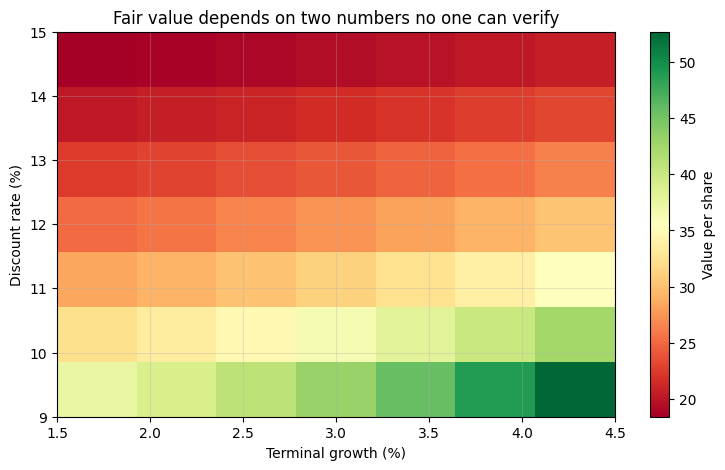

In [5]:
rates = np.arange(0.09, 0.151, 0.01)
gs = np.arange(0.015, 0.0451, 0.005)
G = [0.12,0.10,0.09,0.07,0.06,0.05,0.05,0.04,0.04,0.03]
grid = np.array([[dcf_value(100.0, G, r, g, 150.0, 50.0)["value_per_share"] for g in gs] for r in rates])
im = plt.imshow(grid, origin="lower", aspect="auto", cmap="RdYlGn",
                extent=[gs[0]*100, gs[-1]*100, rates[0]*100, rates[-1]*100])
plt.colorbar(im, label="Value per share")
plt.xlabel("Terminal growth (%)"); plt.ylabel("Discount rate (%)")
plt.title("Fair value depends on two numbers no one can verify"); plt.show()

## The same thing with the toolkit
The model above lives in the `analytical_investor` package, tested and reusable.

In [6]:
from analytical_investor import valuation

print(valuation.sensitivity_table(100, G, [0.10, 0.12, 0.14], [0.02, 0.03, 0.04], 150, 50).round(2))
print(f"Price 25 implies {valuation.implied_growth(25, 100, 0.12, 0.03, 150, 50):.1%} growth")

[[33.48 36.31 40.09]
 [25.78 27.28 29.16]
 [20.69 21.56 22.6 ]]
Price 25 implies 5.9% growth


---
The article's **Limitations** section explains what this model leaves out. [Read it here](https://analytical-investor.blog/?p=1007).